In [1]:
from pathlib import Path

import pandas as pd


PROJECT_ROOT = next(
    path
    for path in (
        Path.cwd(),
        *Path.cwd().parents,
    )
    if (path / "pyproject.toml").is_file()
)

CAMPAIGN_ROOT = (
    PROJECT_ROOT
    / "global_outputs"
    / "runs"
    / "nanovision_selected15_postprocessing_sweep"
)

EXPERIMENTS_ROOT = (
    CAMPAIGN_ROOT
    / "experiments"
)

print("Project root:", PROJECT_ROOT)
print("Campaign root:", CAMPAIGN_ROOT)

Project root: c:\Users\abd93000\PycharmProjects\cnt_project_v2
Campaign root: c:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs\nanovision_selected15_postprocessing_sweep


## Read all 300 evaluation CSV files

In [3]:
csv_paths = sorted(
    EXPERIMENTS_ROOT.glob(
        "*/configurations/*/eval/"
        "irregular_object_eval/"
        "object_metrics_per_image_threshold.csv"
    )
)

print("Evaluation CSV files found:", len(csv_paths))

if len(csv_paths) != 300:
    raise RuntimeError(
        f"Expected 300 evaluation CSV files; found {len(csv_paths)}."
    )


tables = []

for csv_path in csv_paths:
    experiment_name = csv_path.parents[4].name
    configuration_name = csv_path.parents[2].name

    family, seed = experiment_name.rsplit(
        "_seed_",
        maxsplit=1,
    )

    table = pd.read_csv(csv_path)

    table.insert(0, "family", family)
    table.insert(1, "seed", int(seed))
    table.insert(2, "experiment", experiment_name)
    table.insert(
        3,
        "configuration",
        configuration_name,
    )

    tables.append(table)


metrics_df = pd.concat(
    tables,
    ignore_index=True,
)

print("Combined rows:", len(metrics_df))
print("Combined columns:", len(metrics_df.columns))

print()
print("Example CSV:", csv_paths[0])
print("Experiment:", metrics_df.iloc[0]["experiment"])
print("Configuration:", metrics_df.iloc[0]["configuration"])

Evaluation CSV files found: 300
Combined rows: 90000
Combined columns: 23

Example CSV: c:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs\nanovision_selected15_postprocessing_sweep\experiments\batch1_seed_0\configurations\mo_0p00_ma_05_nc_0p50_pnms_0p50\eval\irregular_object_eval\object_metrics_per_image_threshold.csv
Experiment: batch1_seed_0
Configuration: mo_0p00_ma_05_nc_0p50_pnms_0p50


## Inspect and validate

In [6]:
display(metrics_df)

print()
print("Families:")
print(
    metrics_df[
        "family"
    ].value_counts()
)

print()
print("Seeds:")
print(
    sorted(
        metrics_df[
            "seed"
        ].unique()
    )
)

print()
print("Matching metrics:")
print(
    metrics_df[
        "matching_metric"
    ].value_counts()
)

print()
print("Thresholds:")
print(
    sorted(
        metrics_df[
            "threshold"
        ].unique()
    )
)

print()
print(
    "Unique experiments:",
    metrics_df[
        "experiment"
    ].nunique(),
)

print(
    "Unique configurations:",
    metrics_df[
        "configuration"
    ].nunique(),
)

print(
    "Unique experiment/configuration pairs:",
    metrics_df[
        [
            "experiment",
            "configuration",
        ]
    ].drop_duplicates().shape[0],
)

,family,seed,experiment,configuration,filename,matching_metric,threshold,num_gt_objects,num_pred_objects,true_positives,...,recall,f1_score,dsb_precision,matched_feature_pair_count,irregular_matched_prediction_count,mean_absolute_length_error_um,mean_absolute_relative_length_error,mean_absolute_orientation_error_deg,num_pred_objects_before_endpoint_filter,num_pred_objects_rejected_by_endpoint_filter
0,batch1,0,batch1_seed_0,mo_0p00_ma_05_nc_0p50_pnms_0p50,1293-22_3_0_20230306224436.tif,cldice,0.1,96,334,94,...,0.979167,0.437209,0.279762,94,0,0.593701,0.588033,7.754334,334,0
1,batch1,0,batch1_seed_0,mo_0p00_ma_05_nc_0p50_pnms_0p50,1293-22_3_0_20230306224436.tif,cldice,0.2,96,334,94,...,0.979167,0.437209,0.279762,94,0,0.524106,0.527048,6.898192,334,0
2,batch1,0,batch1_seed_0,mo_0p00_ma_05_nc_0p50_pnms_0p50,1293-22_3_0_20230306224436.tif,cldice,0.3,96,334,90,...,0.937500,0.418605,0.264706,90,0,0.420146,0.480485,5.233238,334,0
3,batch1,0,batch1_seed_0,mo_0p00_ma_05_nc_0p50_pnms_0p50,1293-22_3_0_20230306224436.tif,cldice,0.4,96,334,87,...,0.906250,0.404651,0.253644,87,0,0.383898,0.442735,4.697878,334,0
4,batch1,0,batch1_seed_0,mo_0p00_ma_05_nc_0p50_pnms_0p50,1293-22_3_0_20230306224436.tif,cldice,0.5,96,334,71,...,0.739583,0.330233,0.197772,71,0,0.323213,0.394605,4.644191,334,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89995,standard,42,standard_seed_42,mo_0p20_ma_50_nc_0p50_pnms_0p50,400-1605-W8_map_00049_top_left.tif,cldice,0.6,72,136,49,...,0.680556,0.471154,0.308176,49,0,0.163022,0.348843,3.042674,136,0
89996,standard,42,standard_seed_42,mo_0p20_ma_50_nc_0p50_pnms_0p50,400-1605-W8_map_00049_top_left.tif,cldice,0.7,72,136,28,...,0.388889,0.269231,0.155556,28,0,0.084630,0.289112,2.750524,136,0
89997,standard,42,standard_seed_42,mo_0p20_ma_50_nc_0p50_pnms_0p50,400-1605-W8_map_00049_top_left.tif,cldice,0.8,72,136,16,...,0.222222,0.153846,0.083333,16,0,0.055907,0.246970,2.630258,136,0
89998,standard,42,standard_seed_42,mo_0p20_ma_50_nc_0p50_pnms_0p50,400-1605-W8_map_00049_top_left.tif,cldice,0.9,72,136,6,...,0.083333,0.057692,0.029703,6,0,0.040084,0.162949,1.354161,136,0



Families:
family
batch1        22500
centerness    22500
edt_LB        22500
standard      22500
Name: count, dtype: int64

Seeds:
[0, 1, 2, 42, 123]

Matching metrics:
matching_metric
cldice    90000
Name: count, dtype: int64

Thresholds:
[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

Unique experiments: 20
Unique configurations: 15
Unique experiment/configuration pairs: 300


In [5]:
print("Number of columns:", len(metrics_df.columns))

print()
print("Columns:")

for index, column in enumerate(
    metrics_df.columns,
    start=1,
):
    print(f"{index:>2}. {column}")

print()
display(
    metrics_df.head(1).T.rename(
        columns={0: "example_value"}
    )
)

Number of columns: 23

Columns:
 1. family
 2. seed
 3. experiment
 4. configuration
 5. filename
 6. matching_metric
 7. threshold
 8. num_gt_objects
 9. num_pred_objects
10. true_positives
11. false_positives
12. false_negatives
13. precision
14. recall
15. f1_score
16. dsb_precision
17. matched_feature_pair_count
18. irregular_matched_prediction_count
19. mean_absolute_length_error_um
20. mean_absolute_relative_length_error
21. mean_absolute_orientation_error_deg
22. num_pred_objects_before_endpoint_filter
23. num_pred_objects_rejected_by_endpoint_filter



,example_value
family,batch1
seed,0
experiment,batch1_seed_0
configuration,mo_0p00_ma_05_nc_0p50_pnms_0p50
filename,1293-22_3_0_20230306224436.tif
matching_metric,cldice
threshold,0.1
num_gt_objects,96
num_pred_objects,334
true_positives,94


## Filter thresholds

In [7]:
selected_metrics_df = metrics_df.loc[
    metrics_df["threshold"].between(
        0.5,
        1.0,
        inclusive="both",
    )
].copy()

print(
    "Selected thresholds:",
    sorted(
        selected_metrics_df[
            "threshold"
        ].unique()
    ),
)

print(
    "Selected rows:",
    len(selected_metrics_df),
)

Selected thresholds: [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
Selected rows: 54000


## Mean F1 and irregular matched-object count per image across thresholds

In [10]:
group_columns = [
    "family",
    "seed",
    "experiment",
    "configuration",
    "filename",
]

image_metrics_summary_df = (
    selected_metrics_df
    .groupby(
        group_columns,
        as_index=False,
    )
    .agg(
        mean_f1_0p5_to_1=(
            "f1_score",
            "mean",
        ),
        mean_irregular_matched_count_0p5_to_1=(
            "irregular_matched_prediction_count",
            "mean",
        ),
        threshold_count=(
            "threshold",
            "nunique",
        ),
    )
)

if not image_metrics_summary_df[
    "threshold_count"
].eq(6).all():
    raise RuntimeError(
        "Some image/configuration groups do not "
        "contain all six selected thresholds."
    )

print(
    "Image/configuration rows:",
    len(image_metrics_summary_df),
)

display(
    image_metrics_summary_df.head()
)

Image/configuration rows: 9000


,family,seed,experiment,configuration,filename,mean_f1_0p5_to_1,mean_irregular_matched_count_0p5_to_1,threshold_count
0,batch1,0,batch1_seed_0,mo_0p00_ma_05_nc_0p50_pnms_0p50,1293-22_3_0_20230306224436.tif,0.135659,0.000000,6
1,batch1,0,batch1_seed_0,mo_0p00_ma_05_nc_0p50_pnms_0p50,400-1093-w11-c1p1-befo3-10sp-15flow_right.tif,0.391650,0.000000,6
2,batch1,0,batch1_seed_0,mo_0p00_ma_05_nc_0p50_pnms_0p50,400-1093-w17-c1p3-20sp-03flow_left.tif,0.233990,0.666667,6
3,batch1,0,batch1_seed_0,mo_0p00_ma_05_nc_0p50_pnms_0p50,400-1293-17-c10k1r5_pd_sp0_9_fl0_1_left.tif,0.546667,0.000000,6
4,batch1,0,batch1_seed_0,mo_0p00_ma_05_nc_0p50_pnms_0p50,400-1293-17-c11k1r5_pd_sp1_2_fl0_1_left.tif,0.654762,0.000000,6


## Mean F1 and irregular matched-object count across all images

In [11]:
experiment_configuration_summary_df = (
    image_metrics_summary_df
    .groupby(
        [
            "family",
            "seed",
            "experiment",
            "configuration",
        ],
        as_index=False,
    )
    .agg(
        mean_f1_0p5_to_1=(
            "mean_f1_0p5_to_1",
            "mean",
        ),
        mean_irregular_matched_count_0p5_to_1=(
            "mean_irregular_matched_count_0p5_to_1",
            "mean",
        ),
        image_count=(
            "filename",
            "nunique",
        ),
    )
)

if not experiment_configuration_summary_df[
    "image_count"
].eq(30).all():
    raise RuntimeError(
        "Some experiment/configuration groups "
        "do not contain exactly 30 images."
    )

print(
    "Experiment/configuration rows:",
    len(experiment_configuration_summary_df),
)

display(
    experiment_configuration_summary_df.head()
)

Experiment/configuration rows: 300


,family,seed,experiment,configuration,mean_f1_0p5_to_1,mean_irregular_matched_count_0p5_to_1,image_count
0,batch1,0,batch1_seed_0,mo_0p00_ma_05_nc_0p50_pnms_0p50,0.263032,0.022222,30
1,batch1,0,batch1_seed_0,mo_0p00_ma_10_nc_0p50_pnms_0p50,0.353498,0.072222,30
2,batch1,0,batch1_seed_0,mo_0p00_ma_20_nc_0p50_pnms_0p50,0.410673,0.033333,30
3,batch1,0,batch1_seed_0,mo_0p00_ma_30_nc_0p50_pnms_0p50,0.422212,0.038889,30
4,batch1,0,batch1_seed_0,mo_0p00_ma_50_nc_0p25_pnms_0p50,0.420281,0.033333,30


## Compare F1 and matched irregular objects across configurations

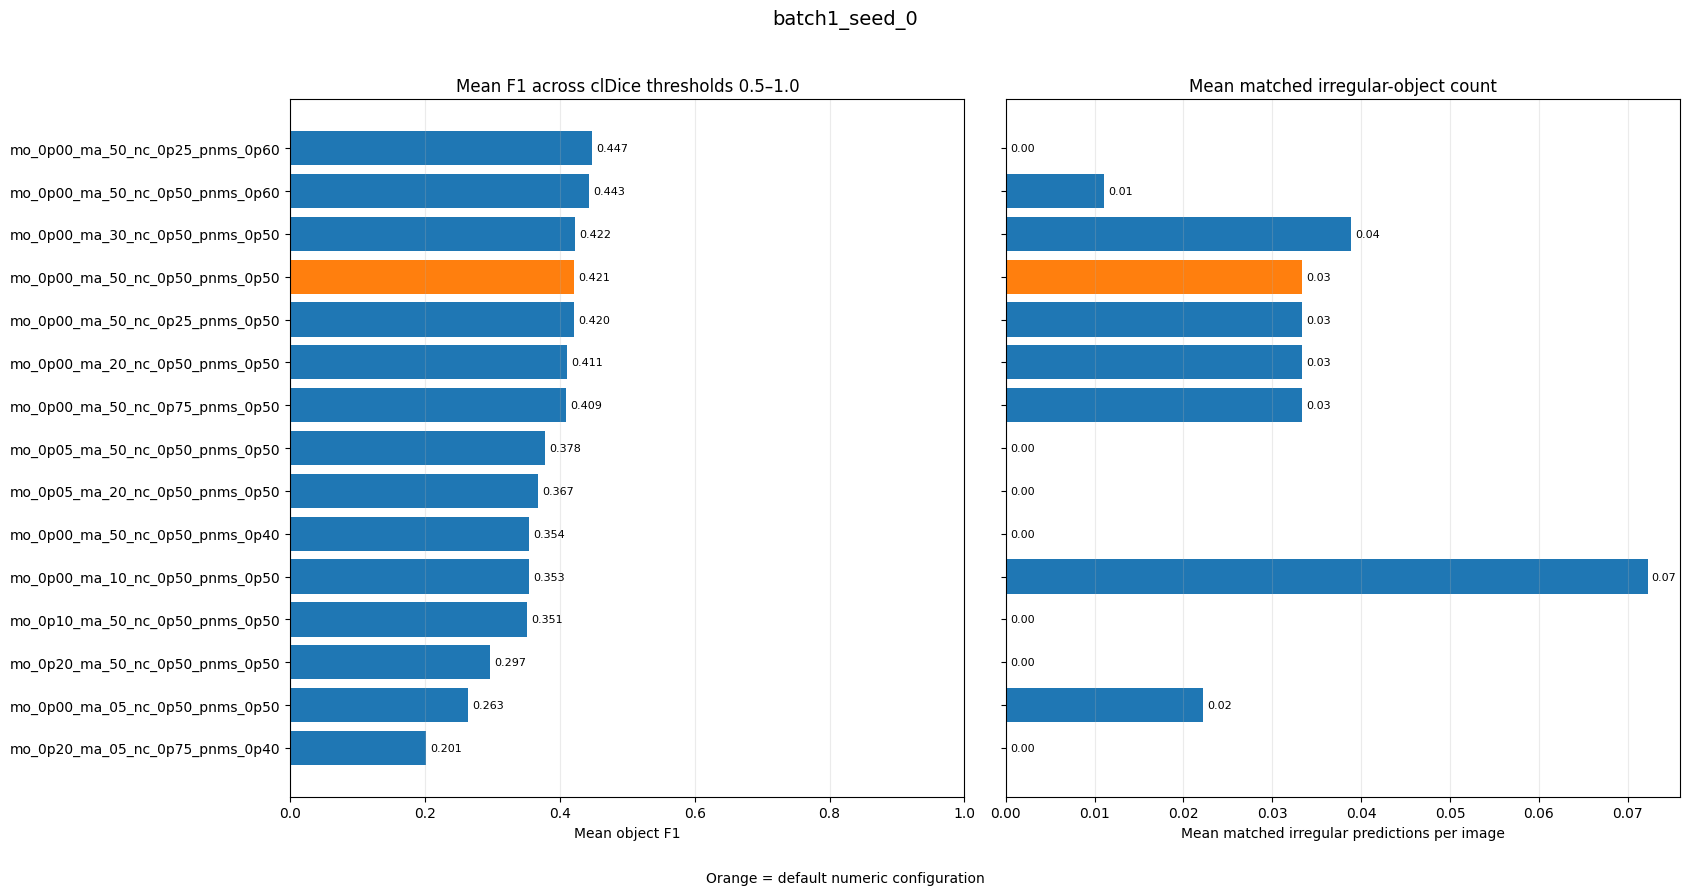

In [12]:
import matplotlib.pyplot as plt


SELECTED_EXPERIMENT = "batch1_seed_0"

plot_df = (
    experiment_configuration_summary_df
    .loc[
        experiment_configuration_summary_df[
            "experiment"
        ].eq(SELECTED_EXPERIMENT)
    ]
    .sort_values(
        "mean_f1_0p5_to_1",
        ascending=False,
    )
    .reset_index(drop=True)
)

if len(plot_df) != 15:
    raise RuntimeError(
        f"Expected 15 configurations for "
        f"{SELECTED_EXPERIMENT}; found {len(plot_df)}."
    )


default_configuration = (
    "mo_0p00_ma_50_nc_0p50_pnms_0p50"
)

colors = [
    "tab:orange"
    if configuration == default_configuration
    else "tab:blue"
    for configuration in plot_df["configuration"]
]


fig, axes = plt.subplots(
    ncols=2,
    figsize=(17, 9),
    sharey=True,
)

y_positions = range(len(plot_df))


f1_bars = axes[0].barh(
    y_positions,
    plot_df["mean_f1_0p5_to_1"],
    color=colors,
)

axes[0].set_yticks(
    list(y_positions),
    labels=plot_df["configuration"],
)

axes[0].invert_yaxis()
axes[0].set_xlim(0, 1)
axes[0].set_xlabel(
    "Mean object F1"
)
axes[0].set_title(
    "Mean F1 across clDice thresholds 0.5–1.0"
)
axes[0].grid(
    axis="x",
    alpha=0.25,
)

axes[0].bar_label(
    f1_bars,
    fmt="%.3f",
    padding=3,
    fontsize=8,
)


irregular_bars = axes[1].barh(
    y_positions,
    plot_df[
        "mean_irregular_matched_count_0p5_to_1"
    ],
    color=colors,
)

axes[1].set_xlabel(
    "Mean matched irregular predictions per image"
)
axes[1].set_title(
    "Mean matched irregular-object count"
)
axes[1].grid(
    axis="x",
    alpha=0.25,
)

axes[1].bar_label(
    irregular_bars,
    fmt="%.2f",
    padding=3,
    fontsize=8,
)


fig.suptitle(
    SELECTED_EXPERIMENT,
    fontsize=14,
)

fig.text(
    0.5,
    0.01,
    "Orange = default numeric configuration",
    ha="center",
)

plt.tight_layout(
    rect=[0, 0.04, 1, 0.96]
)

plt.show()